# Módulo 14 · Lección 2 — Redes modernas de forecasting: N-BEATS

Curso: **Series Temporales con R y Python** (Frogames Formación).

Este notebook es el código de acompañamiento de la lección `02-redes-modernas-n-beats`. Entrena
**N-BEATS** (Oreshkin et al., 2020), una arquitectura de red neuronal diseñada específicamente para
forecasting (no una LSTM genérica reciclada, como la del Módulo 13), sobre el **S&P 500 mensual**
(1990–2026, 441 observaciones) usando `neuralforecast` de Nixtla — en CPU, sin GPU dedicada, con un
presupuesto de entrenamiento deliberadamente pequeño (300 pasos).

**Entorno**: mismo entorno que la Lección 1 de este módulo — ver `requirements.txt` en esta carpeta
(`pandas==2.3.3` en vez de `3.0.5`; todo lo demás coincide con el resto del curso).

In [1]:
# Opcional: así se descargó el histórico. No hace falta ejecutar esta celda
# para seguir el resto del notebook (el CSV ya está en esta carpeta).

import yfinance as yf

df_live = yf.download("^GSPC", start="1990-01-01", end="2026-09-16",
                       interval="1mo", threads=False, auto_adjust=True)
print(df_live.shape)
# df_live["Close"].to_csv("sp500_mensual_1990_2026.csv")

[                       0%                       ]

[*********************100%***********************]  1 of 1 completed

(441, 5)


## Preparación: formato largo y train/test

`neuralforecast`, igual que `statsforecast`, trabaja con el formato largo `unique_id` / `ds` / `y`.
Se reservan los últimos 12 meses como test — la ventana de predicción.

In [2]:
import pandas as pd

close = pd.read_csv("sp500_mensual_1990_2026.csv", index_col=0, parse_dates=True)
close.columns = ["y"]
close.index.name = "ds"
df = close.reset_index()
df["unique_id"] = "SP500"
df = df[["unique_id", "ds", "y"]]

h = 12
train, test = df.iloc[:-h].copy(), df.iloc[-h:].copy()
print("observaciones totales:", len(df), "| train:", len(train), "| test:", len(test))
df.tail()

observaciones totales: 441 | train: 429 | test: 12


,unique_id,ds,y
436,SP500,2026-05-01,7580.060059
437,SP500,2026-06-01,7499.359863
438,SP500,2026-07-01,7489.720215
439,SP500,2026-08-01,7686.140137
440,SP500,2026-09-01,7551.810059


## Entrenamiento de N-BEATS

`input_size=36` (3 años de histórico como ventana de entrada), `max_steps=300` — deliberadamente
pequeño: en un Mac sin GPU dedicada, el objetivo es ver el flujo real de entrenamiento, no perseguir
un modelo de producción. `accelerator="cpu"` fuerza CPU aunque `pytorch-lightning` detecte el backend
MPS de Apple Silicon.

In [3]:
import time
import warnings
warnings.filterwarnings("ignore")

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS
from neuralforecast.losses.pytorch import MAE

modelo = NBEATS(
    h=h,
    input_size=36,
    max_steps=300,
    val_check_steps=1000,
    early_stop_patience_steps=-1,
    accelerator="cpu",
    random_seed=42,
    enable_progress_bar=False,
    loss=MAE(),
)
nf = NeuralForecast(models=[modelo], freq="MS")

t0 = time.time()
nf.fit(df=train)
tiempo_entrenamiento = time.time() - t0
print(f"tiempo de entrenamiento: {tiempo_entrenamiento:.2f} s")

Seed set to 42


GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores



  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 2.5 M  | train
--------------------------------------------------------------
2.5 M     Trainable params
1.2 K     Non-trainable params
2.5 M     Total params
9.889     Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


`Trainer.fit` stopped: `max_steps=300` reached.


tiempo de entrenamiento: 5.46 s


## Predicción y comparación honesta contra el test real

In [4]:
forecast = nf.predict()
forecast = forecast.merge(test[["ds", "y"]], on="ds", how="left")

mae = (forecast["NBEATS"] - forecast["y"]).abs().mean()
mape = ((forecast["NBEATS"] - forecast["y"]).abs() / forecast["y"]).mean() * 100
print(f"N-BEATS  -> MAE: {mae:.2f}  MAPE: {mape:.2f}%")
forecast

GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


N-BEATS  -> MAE: 643.89  MAPE: 8.70%


,unique_id,ds,NBEATS,y
0,SP500,2025-10-01,6679.100586,6840.200195
1,SP500,2025-11-01,6629.537109,6849.089844
2,SP500,2025-12-01,6585.146973,6845.500000
3,SP500,2026-01-01,6625.755371,6939.029785
4,SP500,2026-02-01,6615.111816,6878.879883
5,SP500,2026-03-01,6663.937500,6528.520020
6,SP500,2026-04-01,6642.845703,7209.009766
7,SP500,2026-05-01,6638.980957,7580.060059
8,SP500,2026-06-01,6450.380859,7499.359863
9,SP500,2026-07-01,6303.271973,7489.720215


## Comparación contra los benchmarks clásicos del curso

Mismo train/test, mismo horizonte: un `AutoARIMA` de `pmdarima` (el que ya conoces del Módulo 11) y
un *naive* (repetir el último valor observado) sobre los mismos 12 meses.

In [5]:
import pmdarima as pm

y_train, y_test = train.set_index("ds")["y"], test.set_index("ds")["y"]

modelo_arima = pm.auto_arima(y_train, seasonal=False, stepwise=True,
                              suppress_warnings=True, error_action="ignore")
fc_arima = pd.Series(modelo_arima.predict(n_periods=h), index=y_test.index)
mae_arima = (fc_arima - y_test).abs().mean()
mape_arima = ((fc_arima - y_test).abs() / y_test).mean() * 100

fc_naive = pd.Series(y_train.iloc[-1], index=y_test.index)
mae_naive = (fc_naive - y_test).abs().mean()
mape_naive = ((fc_naive - y_test).abs() / y_test).mean() * 100

print(f"AutoARIMA{modelo_arima.order} -> MAE: {mae_arima:.2f}  MAPE: {mape_arima:.2f}%")
print(f"Naive (último valor)         -> MAE: {mae_naive:.2f}  MAPE: {mape_naive:.2f}%")
print(f"N-BEATS (300 pasos)          -> MAE: {mae:.2f}  MAPE: {mape:.2f}%")

AutoARIMA(2, 2, 2) -> MAE: 225.88  MAPE: 3.11%
Naive (último valor)         -> MAE: 496.31  MAPE: 6.72%
N-BEATS (300 pasos)          -> MAE: 643.89  MAPE: 8.70%


## Gráfico: histórico, test real y predicción de N-BEATS

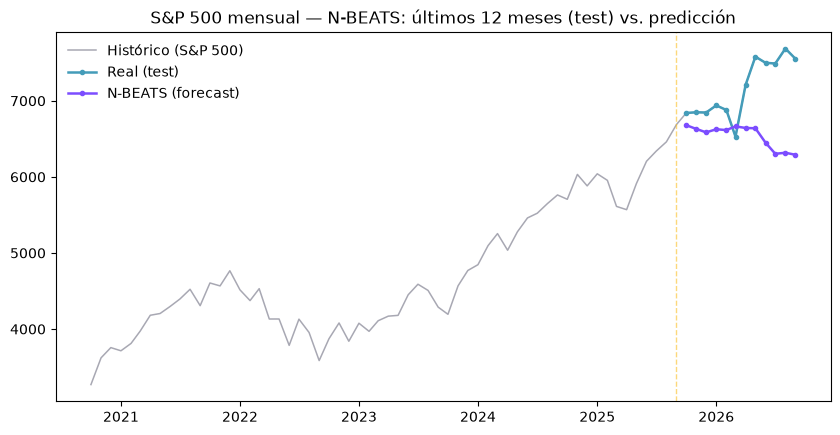

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4.8))
hist = df.iloc[-72:]
ax.plot(hist["ds"], hist["y"], color="#a8a8b3", linewidth=1.1, label="Histórico (S&P 500)")
ax.plot(forecast["ds"], forecast["y"], color="#449cb9", linewidth=1.8, marker="o", markersize=3, label="Real (test)")
ax.plot(forecast["ds"], forecast["NBEATS"], color="#7c4dff", linewidth=1.8, marker="o", markersize=3, label="N-BEATS (forecast)")
ax.axvline(train["ds"].iloc[-1], color="#fbbf24", linestyle="--", linewidth=1, alpha=0.6)
ax.set_title("S&P 500 mensual — N-BEATS: últimos 12 meses (test) vs. predicción")
ax.legend(frameon=False, loc="upper left")
plt.show()